In [85]:
# Import libraries
import numpy as np
import math
import pandas as pd
import os
# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import DayLocator, MonthLocator, DateFormatter

In [97]:
# Import dataset
dataset = pd.read_csv("../data/mag7_stocks.csv")

# Check if data is loaded
print(dataset.head(), "\n")
dataset.info()

# Convert date datatype from object to datetime
dataset[dataset.columns[1]] = pd.to_datetime(dataset[dataset.columns[1]])
dataset = dataset[dataset["Date"] < "2025-09-01"]
# dataset = dataset[dataset['Date'] < '2025-10-01']
dataset.info()

   Unnamed: 0        Date Ticker        Open        High         Low  \
0           0  2025-01-02   AAPL  248.929993  249.100006  241.820007   
1           1  2025-01-02   AAPL  248.929993  249.100006  241.820007   
2           2  2025-01-03   AAPL  243.360001  244.179993  241.889999   
3           3  2025-01-03   AAPL  243.360001  244.179993  241.889999   
4           4  2025-01-06   AAPL  244.309998  247.330002  243.199997   

        Close    Volume  
0  243.850006  55740700  
1  243.850006  55740700  
2  243.360001  40244100  
3  243.360001  40244100  
4  245.000000  45045600   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2730 entries, 0 to 2729
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2730 non-null   int64  
 1   Date        2730 non-null   object 
 2   Ticker      2730 non-null   object 
 3   Open        2730 non-null   float64
 4   High        2730 non-null   float64
 5   Low        

In [98]:
dataset.tail()

,Unnamed: 0,Date,Ticker,Open,High,Low,Close,Volume
2665,2665,2025-08-27,TSLA,351.940002,355.390015,349.160004,349.600006,65519000
2666,2666,2025-08-28,TSLA,350.910004,353.549988,340.260010,345.980011,67903200
2667,2667,2025-08-28,TSLA,350.910004,353.549988,340.260010,345.980011,67903200
2668,2668,2025-08-29,TSLA,347.230011,348.750000,331.700012,333.869995,81145700
2669,2669,2025-08-29,TSLA,347.230011,348.750000,331.700012,333.869995,81145700


In [99]:
dataset["Date"].unique()

<DatetimeArray>
['2025-01-02 00:00:00', '2025-01-03 00:00:00', '2025-01-06 00:00:00',
 '2025-01-07 00:00:00', '2025-01-08 00:00:00', '2025-01-10 00:00:00',
 '2025-01-13 00:00:00', '2025-01-14 00:00:00', '2025-01-15 00:00:00',
 '2025-01-16 00:00:00',
 ...
 '2025-08-18 00:00:00', '2025-08-19 00:00:00', '2025-08-20 00:00:00',
 '2025-08-21 00:00:00', '2025-08-22 00:00:00', '2025-08-25 00:00:00',
 '2025-08-26 00:00:00', '2025-08-27 00:00:00', '2025-08-28 00:00:00',
 '2025-08-29 00:00:00']
Length: 165, dtype: datetime64[ns]

In [100]:
# Folder to place our matplotlib figures in
figures_folder_name = "figures"

In [101]:
# Show companies
companies = dataset["Ticker"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [102]:
# Identify column names from dataset
COL_DATE = "Date"
COL_NAME = "Ticker"
COL_OPEN = "Open"
COL_HIGH = "High"
COL_LOW = "Low"
COL_CLOSE = "Close"
COL_VOLUME = "Volume"

In [103]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
})

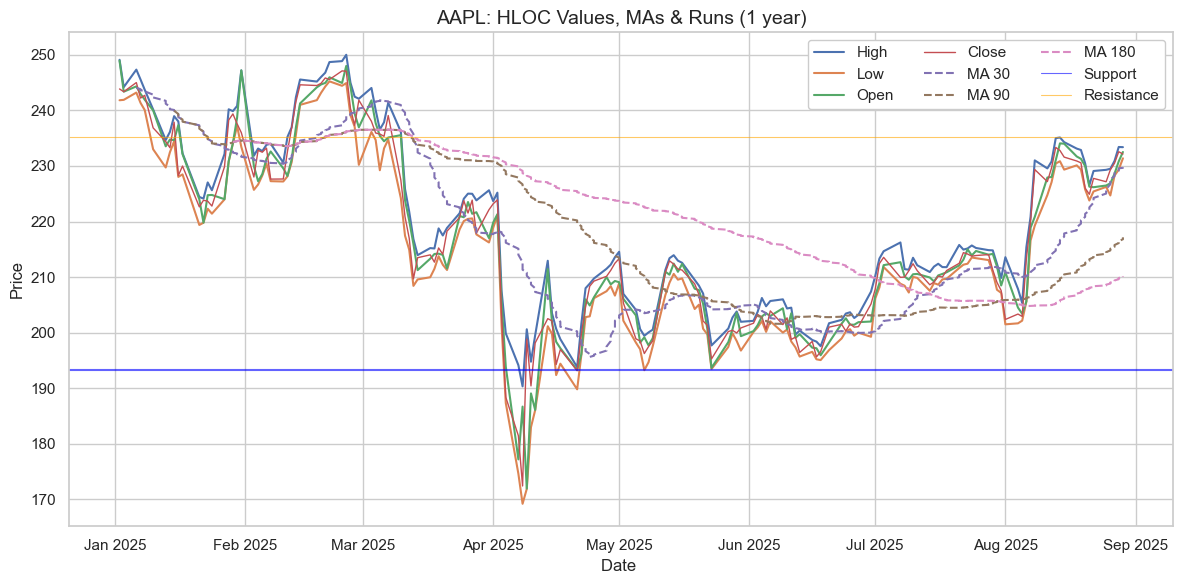

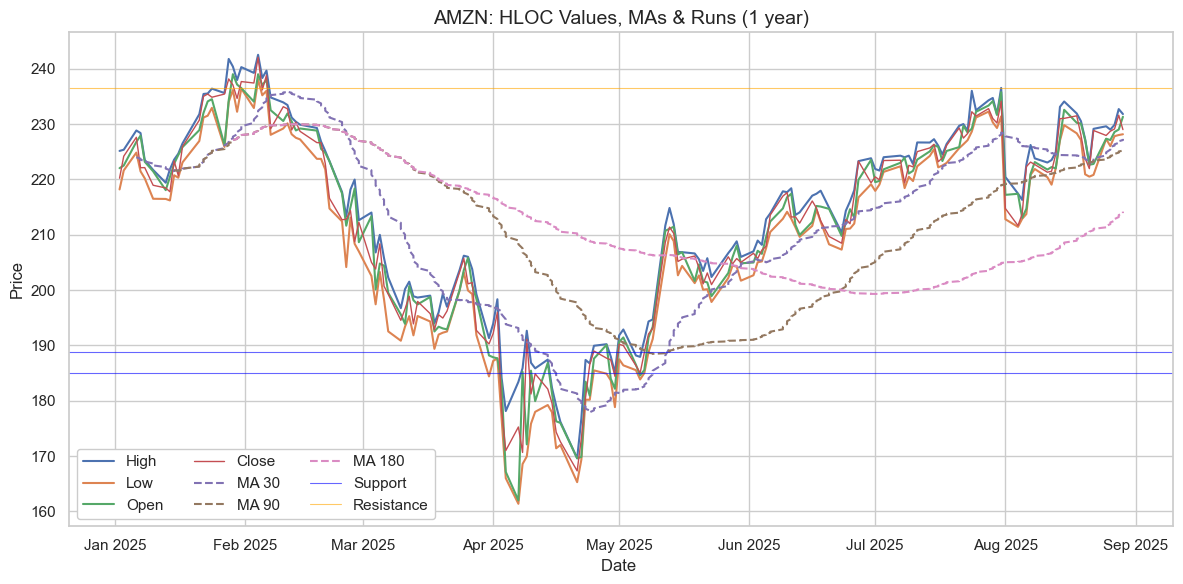

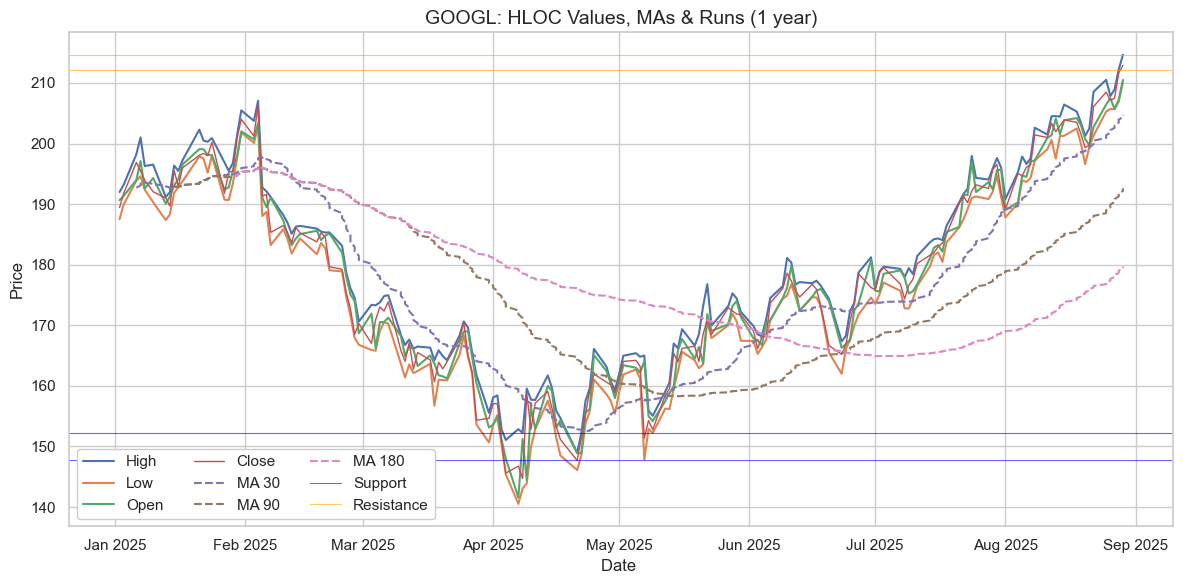

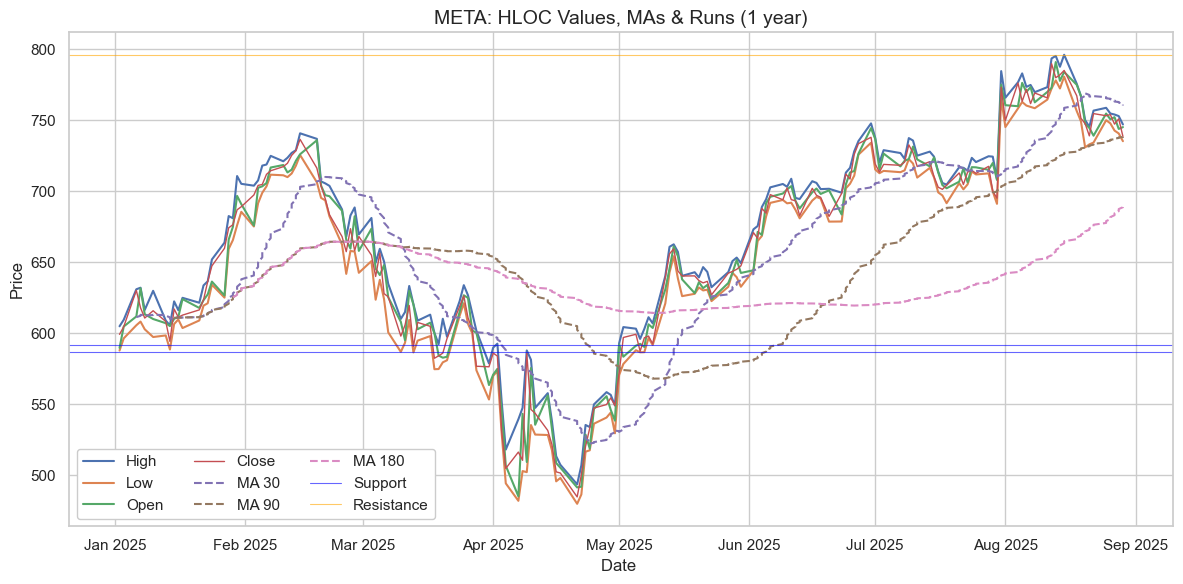

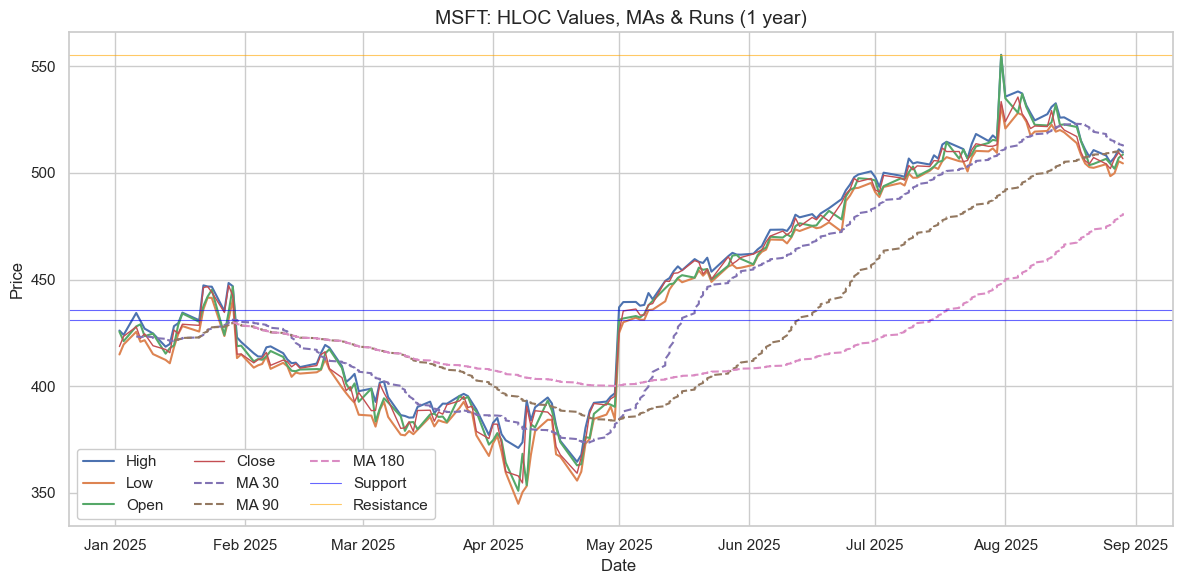

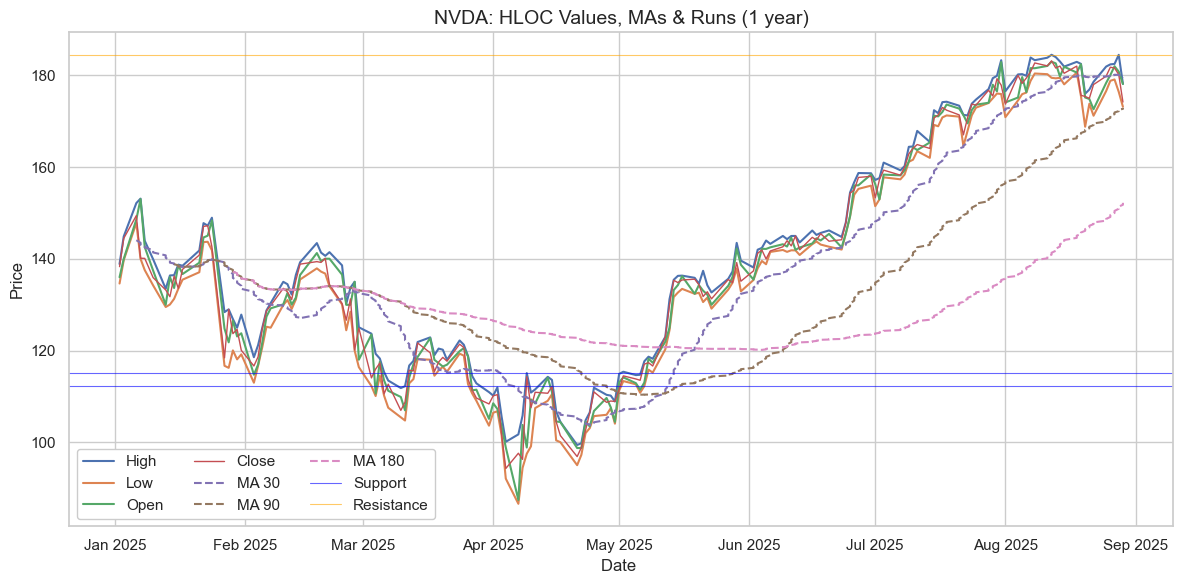

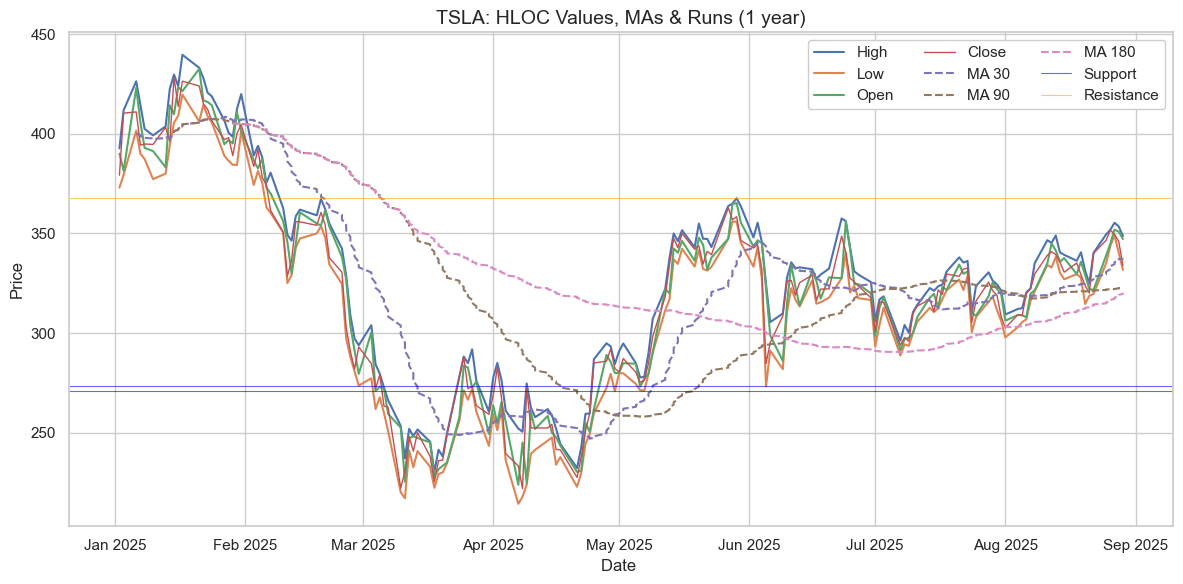

In [104]:
# Plot for every companyfor name in companies:    df = dataset[dataset[COL_NAME] == name]    df = df.sort_values(by=COL_DATE).reset_index(drop=True)    recency_type = "years"    recency_value = 1    last_date = df[COL_DATE].max()    if recency_type == "years":        start_date = last_date - pd.DateOffset(years=recency_value)    elif recency_type == "months":        start_date = last_date - pd.DateOffset(months=recency_value)    else:        start_date = last_date - pd.DateOffset(days=recency_value)    df = df[df[COL_DATE] >= start_date]    for win in (30, 90, 180):        df[f"MA_{win}"] = df[COL_CLOSE].rolling(window=win, min_periods=max(5, win//5)).mean()    df["Close_Diff"] = df[COL_CLOSE].diff()    df["Run"] = df["Close_Diff"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))    df["Run_Group"] = (df["Run"] != df["Run"].shift()).cumsum()    run_segments = df.groupby("Run_Group").filter(lambda x: len(x) >= 2)    visible_min, visible_max = df[COL_DATE].min(), df[COL_DATE].max()    run_segments = run_segments[(run_segments[COL_DATE] >= visible_min) & (run_segments[COL_DATE] <= visible_max)]    print(f"{name}: Found {run_segments['Run_Group'].nunique()} run segments")    if recency_type == "days":        sr_window = 5    elif recency_type == "months":        sr_window = 20    else:        sr_window = 60    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()    support_levels = support.tail(100).nsmallest(3).unique()    resistance_levels = resistance.tail(100).nlargest(3).unique()    fig, ax = plt.subplots()    ax.plot(df[COL_DATE], df[COL_HIGH], label="High")    ax.plot(df[COL_DATE], df[COL_LOW], label="Low")    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open")    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", linewidth=1)    for win in (30, 90, 180):        ax.plot(df[COL_DATE], df[f"MA_{win}"], label=f"MA {win}", linestyle="--")    for level in support_levels:        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6, label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")    for level in resistance_levels:        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6, label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")    for _, group in run_segments.groupby("Run_Group"):        color = 'green' if group["Run"].iloc[0] == 1 else 'red'        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1], color=color, alpha=0.2)    if (recency_type == "days" and recency_value <= 31) or (recency_type == "months" and recency_value == 1):        ax.xaxis.set_major_locator(DayLocator(interval=1))        ax.xaxis.set_major_formatter(DateFormatter('%d'))    elif recency_type == "years" and recency_value == 1:        ax.xaxis.set_major_locator(MonthLocator())        ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))    ax.set_title(f"{name}: HLOC Values, MAs & Runs ({recency_value} {recency_type[0:-1] if recency_value == 1 else recency_type})")    ax.set_xlabel(f"Date {'(day)' if recency_type == 'days' or recency_type == 'months' and recency_value == 1 else ''}")    ax.set_ylabel("Price")    ax.legend(ncol=3)    plt.tight_layout()    plt.show()    print('\n')

In [93]:
from pathlib import Path


with open(Path.cwd().parent / "graphs" /  "figures" / "AAPL", "rb") as f:
    fig = pickle.load(f)

fig.axes[0].lines

<Axes.ArtistList of 10 lines>

In [53]:
fig.axes[0].lines

<Axes.ArtistList of 10 lines>